In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from pathlib import Path

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_full = torchvision.datasets.CIFAR10(
    root='./data_CIFAR10', train=True, download=True, transform=transform_cifar
)
test_set = torchvision.datasets.CIFAR10(
    root='./data_CIFAR10', train=False, download=True, transform=transform_cifar
)

input_size = 3 * 32 * 32
num_classes = 10

In [4]:
batch_size = 64
val_split = 0.2

val_size = int(len(train_full) * val_split)
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

for x, y in train_loader:
    print(f"Batch shape: {x.shape}, labels: {y.shape}")
    print(f"Min value: {x.min():.3f}, Max value: {x.max():.3f}")
    break

Batch shape: torch.Size([64, 3, 32, 32]), labels: torch.Size([64])
Min value: -1.000, Max value: 1.000


In [5]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes,
                 dropout_prob=0.0, use_batchnorm=False):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_prob > 0.0:
                layers.append(nn.Dropout(dropout_prob))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [11]:
hidden_sizes = [256,128]

model = MLP(input_size, hidden_sizes, num_classes,
            dropout_prob=0.0, use_batchnorm=False).to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [12]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
def run_experiment(model, train_loader, val_loader, criterion, optimizer,
                   epochs, device, experiment_id, early_stopping_patience=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if early_stopping_patience and epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break


    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return history, best_val_acc, val_loss

In [14]:
criterion = nn.CrossEntropyLoss()
num_epochs = 20

# Часть A (S08)

In [15]:
print("=== E1: Base model (no dropout, no batchnorm) ===")
model_e1 = MLP(input_size, hidden_sizes, num_classes,
               dropout_prob=0.0, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=1e-3)
history_e1, best_val_acc_e1, _ = run_experiment(
    model_e1, train_loader, val_loader, criterion, optimizer_e1,
    epochs=num_epochs, device=device, experiment_id='E1'
)

results = []
results.append({
    'experiment_id': 'E1',
    'model_summary': 'hidden=[256,128], ReLU, no reg',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': history_e1['val_loss'][-1]
})

=== E1: Base model (no dropout, no batchnorm) ===
Epoch  1/20 | Train Loss: 1.6627 Acc: 0.4080 | Val Loss: 1.5322 Acc: 0.4607
Epoch  2/20 | Train Loss: 1.4545 Acc: 0.4827 | Val Loss: 1.4696 Acc: 0.4884
Epoch  3/20 | Train Loss: 1.3506 Acc: 0.5223 | Val Loss: 1.4097 Acc: 0.5079
Epoch  4/20 | Train Loss: 1.2596 Acc: 0.5548 | Val Loss: 1.3949 Acc: 0.5145
Epoch  5/20 | Train Loss: 1.1845 Acc: 0.5837 | Val Loss: 1.3803 Acc: 0.5272
Epoch  6/20 | Train Loss: 1.1107 Acc: 0.6081 | Val Loss: 1.3982 Acc: 0.5179
Epoch  7/20 | Train Loss: 1.0433 Acc: 0.6296 | Val Loss: 1.4313 Acc: 0.5141
Epoch  8/20 | Train Loss: 0.9723 Acc: 0.6553 | Val Loss: 1.4434 Acc: 0.5172
Epoch  9/20 | Train Loss: 0.9106 Acc: 0.6774 | Val Loss: 1.5022 Acc: 0.5228
Epoch 10/20 | Train Loss: 0.8490 Acc: 0.6967 | Val Loss: 1.5183 Acc: 0.5237
Epoch 11/20 | Train Loss: 0.7974 Acc: 0.7187 | Val Loss: 1.5995 Acc: 0.5205
Epoch 12/20 | Train Loss: 0.7351 Acc: 0.7375 | Val Loss: 1.6513 Acc: 0.5273
Epoch 13/20 | Train Loss: 0.6879 Acc: 

In [16]:
print("=== E2: With Dropout (p=0.3) ===")
model_e2 = MLP(input_size, hidden_sizes, num_classes,
               dropout_prob=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)
history_e2, best_val_acc_e2, _ = run_experiment(
    model_e2, train_loader, val_loader, criterion, optimizer_e2,
    epochs=num_epochs, device=device, experiment_id='E2'
)
results.append({
    'experiment_id': 'E2',
    'model_summary': 'hidden=[256,128], ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': history_e2['val_loss'][-1]
})

=== E2: With Dropout (p=0.3) ===
Epoch  1/20 | Train Loss: 1.7940 Acc: 0.3622 | Val Loss: 1.6190 Acc: 0.4384
Epoch  2/20 | Train Loss: 1.6379 Acc: 0.4190 | Val Loss: 1.5356 Acc: 0.4607
Epoch  3/20 | Train Loss: 1.5791 Acc: 0.4398 | Val Loss: 1.4828 Acc: 0.4797
Epoch  4/20 | Train Loss: 1.5275 Acc: 0.4597 | Val Loss: 1.4425 Acc: 0.4915
Epoch  5/20 | Train Loss: 1.4947 Acc: 0.4737 | Val Loss: 1.4442 Acc: 0.4973
Epoch  6/20 | Train Loss: 1.4593 Acc: 0.4809 | Val Loss: 1.4216 Acc: 0.5045
Epoch  7/20 | Train Loss: 1.4362 Acc: 0.4918 | Val Loss: 1.4065 Acc: 0.5022
Epoch  8/20 | Train Loss: 1.4081 Acc: 0.4989 | Val Loss: 1.3881 Acc: 0.5142
Epoch  9/20 | Train Loss: 1.3860 Acc: 0.5053 | Val Loss: 1.3834 Acc: 0.5130
Epoch 10/20 | Train Loss: 1.3669 Acc: 0.5140 | Val Loss: 1.3840 Acc: 0.5121
Epoch 11/20 | Train Loss: 1.3454 Acc: 0.5209 | Val Loss: 1.3629 Acc: 0.5229
Epoch 12/20 | Train Loss: 1.3243 Acc: 0.5284 | Val Loss: 1.3686 Acc: 0.5136
Epoch 13/20 | Train Loss: 1.3089 Acc: 0.5345 | Val Loss

In [17]:
print("=== E3: With BatchNorm ===")
model_e3 = MLP(input_size, hidden_sizes, num_classes,
               dropout_prob=0.0, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)
history_e3, best_val_acc_e3, _ = run_experiment(
    model_e3, train_loader, val_loader, criterion, optimizer_e3,
    epochs=num_epochs, device=device, experiment_id='E3'
)
results.append({
    'experiment_id': 'E3',
    'model_summary': 'hidden=[256,128], ReLU, batchnorm',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': history_e3['val_loss'][-1]
})

=== E3: With BatchNorm ===
Epoch  1/20 | Train Loss: 1.6479 Acc: 0.4123 | Val Loss: 1.4851 Acc: 0.4644
Epoch  2/20 | Train Loss: 1.4313 Acc: 0.4874 | Val Loss: 1.3930 Acc: 0.4980
Epoch  3/20 | Train Loss: 1.3213 Acc: 0.5283 | Val Loss: 1.3548 Acc: 0.5174
Epoch  4/20 | Train Loss: 1.2478 Acc: 0.5541 | Val Loss: 1.3367 Acc: 0.5246
Epoch  5/20 | Train Loss: 1.1809 Acc: 0.5812 | Val Loss: 1.3181 Acc: 0.5371
Epoch  6/20 | Train Loss: 1.1195 Acc: 0.6006 | Val Loss: 1.3153 Acc: 0.5364
Epoch  7/20 | Train Loss: 1.0668 Acc: 0.6227 | Val Loss: 1.3228 Acc: 0.5407
Epoch  8/20 | Train Loss: 1.0078 Acc: 0.6414 | Val Loss: 1.3204 Acc: 0.5447
Epoch  9/20 | Train Loss: 0.9584 Acc: 0.6604 | Val Loss: 1.3410 Acc: 0.5459
Epoch 10/20 | Train Loss: 0.9152 Acc: 0.6773 | Val Loss: 1.3861 Acc: 0.5362
Epoch 11/20 | Train Loss: 0.8633 Acc: 0.6941 | Val Loss: 1.3835 Acc: 0.5457
Epoch 12/20 | Train Loss: 0.8216 Acc: 0.7109 | Val Loss: 1.3950 Acc: 0.5452
Epoch 13/20 | Train Loss: 0.7806 Acc: 0.7228 | Val Loss: 1.41

In [18]:
# Выбираем лучший вариант
if best_val_acc_e2 >= best_val_acc_e3:
    best_reg_type = 'dropout'
    best_model_class = MLP(input_size, hidden_sizes, num_classes,
                           dropout_prob=0.3, use_batchnorm=False)
    model_summary_e4 = 'hidden=[256,128], ReLU, dropout=0.3, early_stop'
else:
    best_reg_type = 'batchnorm'
    best_model_class = MLP(input_size, hidden_sizes, num_classes,
                           dropout_prob=0.0, use_batchnorm=True)
    model_summary_e4 = 'hidden=[256,128], ReLU, batchnorm, early_stop'

print(f"=== E4: Best model ({best_reg_type}) with EarlyStopping ===")
model_e4 = best_model_class.to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)

# Обучаем с early stopping (patience=4)
history_e4, best_val_acc_e4, _ = run_experiment(
    model_e4, train_loader, val_loader, criterion, optimizer_e4,
    epochs=30, device=device, experiment_id='E4', early_stopping_patience=4
)

epochs_trained_e4 = len(history_e4['train_loss'])
results.append({
    'experiment_id': 'E4',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_trained_e4,
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': history_e4['val_loss'][-1]
})

=== E4: Best model (batchnorm) with EarlyStopping ===
Epoch  1/30 | Train Loss: 1.6448 Acc: 0.4111 | Val Loss: 1.4803 Acc: 0.4737
Epoch  2/30 | Train Loss: 1.4324 Acc: 0.4881 | Val Loss: 1.3910 Acc: 0.5071
Epoch  3/30 | Train Loss: 1.3259 Acc: 0.5268 | Val Loss: 1.3445 Acc: 0.5227
Epoch  4/30 | Train Loss: 1.2445 Acc: 0.5566 | Val Loss: 1.3187 Acc: 0.5305
Epoch  5/30 | Train Loss: 1.1784 Acc: 0.5810 | Val Loss: 1.3028 Acc: 0.5429
Epoch  6/30 | Train Loss: 1.1156 Acc: 0.6036 | Val Loss: 1.3147 Acc: 0.5351
Epoch  7/30 | Train Loss: 1.0642 Acc: 0.6228 | Val Loss: 1.3029 Acc: 0.5425
Epoch  8/30 | Train Loss: 1.0111 Acc: 0.6411 | Val Loss: 1.3420 Acc: 0.5423
Epoch  9/30 | Train Loss: 0.9599 Acc: 0.6593 | Val Loss: 1.3294 Acc: 0.5434
Epoch 10/30 | Train Loss: 0.9134 Acc: 0.6783 | Val Loss: 1.3713 Acc: 0.5361
Epoch 11/30 | Train Loss: 0.8684 Acc: 0.6902 | Val Loss: 1.3588 Acc: 0.5425
Epoch 12/30 | Train Loss: 0.8207 Acc: 0.7098 | Val Loss: 1.3612 Acc: 0.5476
Epoch 13/30 | Train Loss: 0.7799 A

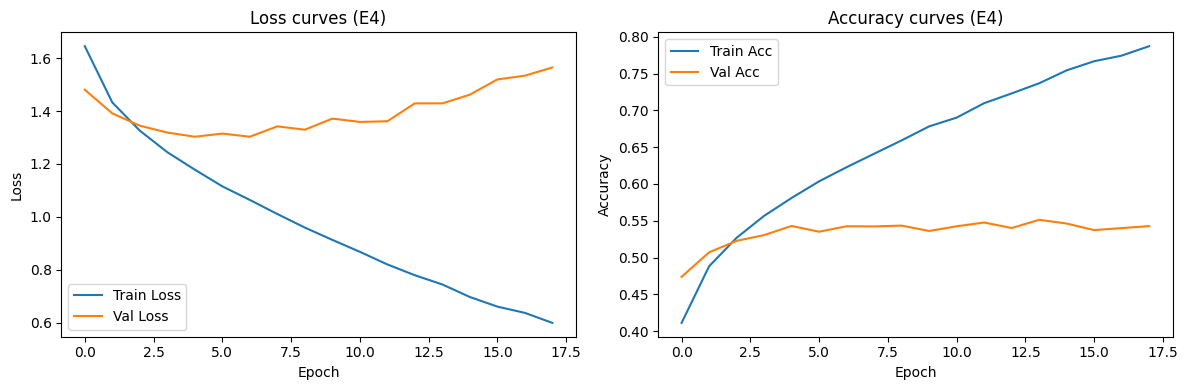

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_e4['train_loss'], label='Train Loss')
plt.plot(history_e4['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves (E4)')

plt.subplot(1,2,2)
plt.plot(history_e4['train_acc'], label='Train Acc')
plt.plot(history_e4['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves (E4)')

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()

In [ ]:
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')

# Часть B (S09):

In [20]:
print("=== O1: Adam, LR too high (1e-1) ===")
model_o1 = best_model_class.to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
history_o1, best_val_acc_o1, _ = run_experiment(
    model_o1, train_loader, val_loader, criterion, optimizer_o1,
    epochs=8, device=device, experiment_id='O1'
)
results.append({
    'experiment_id': 'O1',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc_o1,
    'best_val_loss': history_o1['val_loss'][-1]
})

=== O1: Adam, LR too high (1e-1) ===
Epoch  1/8 | Train Loss: 1.8847 Acc: 0.3260 | Val Loss: 1.6793 Acc: 0.3781
Epoch  2/8 | Train Loss: 1.6778 Acc: 0.3911 | Val Loss: 1.6432 Acc: 0.4111
Epoch  3/8 | Train Loss: 1.5978 Acc: 0.4200 | Val Loss: 1.5552 Acc: 0.4467
Epoch  4/8 | Train Loss: 1.5487 Acc: 0.4432 | Val Loss: 1.5242 Acc: 0.4567
Epoch  5/8 | Train Loss: 1.4974 Acc: 0.4601 | Val Loss: 1.5065 Acc: 0.4641
Epoch  6/8 | Train Loss: 1.4704 Acc: 0.4758 | Val Loss: 1.4980 Acc: 0.4681
Epoch  7/8 | Train Loss: 1.4429 Acc: 0.4809 | Val Loss: 1.5432 Acc: 0.4625
Epoch  8/8 | Train Loss: 1.4139 Acc: 0.4944 | Val Loss: 1.5134 Acc: 0.4691


In [23]:
print("=== O2: Adam, LR too low (1e-5) ===")
model_o2 = best_model_class.to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
history_o2, best_val_acc_o2, _ = run_experiment(
    model_o2, train_loader, val_loader, criterion, optimizer_o2,
    epochs=8, device=device, experiment_id='O2'
)
results.append({
    'experiment_id': 'O2',
    'model_summary': model_summary_e4,
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': best_val_acc_o2,
    'best_val_loss': history_o2['val_loss'][-1]
})

=== O2: Adam, LR too low (1e-5) ===
Epoch  1/8 | Train Loss: 1.3943 Acc: 0.5083 | Val Loss: 1.4997 Acc: 0.4762
Epoch  2/8 | Train Loss: 1.3860 Acc: 0.5101 | Val Loss: 1.4978 Acc: 0.4780
Epoch  3/8 | Train Loss: 1.3780 Acc: 0.5115 | Val Loss: 1.4871 Acc: 0.4785
Epoch  4/8 | Train Loss: 1.3737 Acc: 0.5121 | Val Loss: 1.4867 Acc: 0.4802
Epoch  5/8 | Train Loss: 1.3655 Acc: 0.5175 | Val Loss: 1.4782 Acc: 0.4826
Epoch  6/8 | Train Loss: 1.3606 Acc: 0.5174 | Val Loss: 1.4803 Acc: 0.4818
Epoch  7/8 | Train Loss: 1.3573 Acc: 0.5204 | Val Loss: 1.4774 Acc: 0.4842
Epoch  8/8 | Train Loss: 1.3514 Acc: 0.5208 | Val Loss: 1.4735 Acc: 0.4864


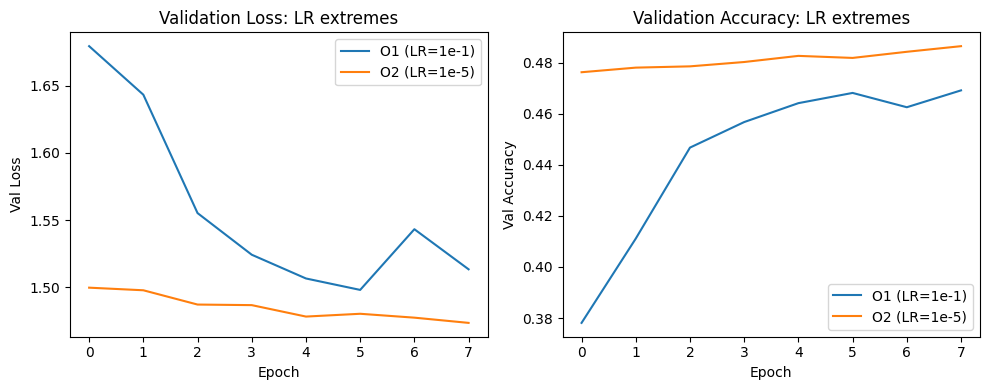

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_o1['val_loss'], label='O1 (LR=1e-1)')
plt.plot(history_o2['val_loss'], label='O2 (LR=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()
plt.title('Validation Loss: LR extremes')

plt.subplot(1,2,2)
plt.plot(history_o1['val_acc'], label='O1 (LR=1e-1)')
plt.plot(history_o2['val_acc'], label='O2 (LR=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.title('Validation Accuracy: LR extremes')

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

Эксперименты с экстремальными значениями learning rate подтвердили теоретические ожидания:

- O1 (LR = 1e-1): Слишком большой шаг градиента привел к нестабильному обучению — loss осциллировал, accuracy рос быстро, но нестабильно, модель не смогла сойтись.

- O2 (LR = 1e-5): Слишком маленький шаг практически остановил обучение — за 8 эпох параметры модели почти не изменились, accuracy осталось почти на уровне первой эпохи.

Эти результаты наглядно демонстрируют, почему выбор правильного learning rate критически важен: слишком высокое значение делает обучение нестабильным, слишком низкое — непозволительно медленным. Оптимальное значение (в данном случае ~1e-3) лежит между этими крайностями, что и было использовано в экспериментах части A.

In [26]:
print("=== O3: SGD with momentum=0.9, weight_decay=1e-4 ===")
model_o3 = best_model_class.to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_o3, best_val_acc_o3, _ = run_experiment(
    model_o3, train_loader, val_loader, criterion, optimizer_o3,
    epochs=15, device=device, experiment_id='O3'
)
results.append({
    'experiment_id': 'O3',
    'model_summary': model_summary_e4,
    'optimizer': 'SGD',
    'lr': 1e-2,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': 15,
    'best_val_accuracy': best_val_acc_o3,
    'best_val_loss': history_o3['val_loss'][-1]
})

=== O3: SGD with momentum=0.9, weight_decay=1e-4 ===
Epoch  1/15 | Train Loss: 1.2867 Acc: 0.5394 | Val Loss: 1.4208 Acc: 0.4974
Epoch  2/15 | Train Loss: 1.2836 Acc: 0.5399 | Val Loss: 1.4200 Acc: 0.5016
Epoch  3/15 | Train Loss: 1.2798 Acc: 0.5424 | Val Loss: 1.4187 Acc: 0.4977
Epoch  4/15 | Train Loss: 1.2810 Acc: 0.5421 | Val Loss: 1.4189 Acc: 0.5017
Epoch  5/15 | Train Loss: 1.2826 Acc: 0.5411 | Val Loss: 1.4149 Acc: 0.4989
Epoch  6/15 | Train Loss: 1.2750 Acc: 0.5417 | Val Loss: 1.4197 Acc: 0.5022
Epoch  7/15 | Train Loss: 1.2751 Acc: 0.5412 | Val Loss: 1.4183 Acc: 0.5015
Epoch  8/15 | Train Loss: 1.2764 Acc: 0.5415 | Val Loss: 1.4148 Acc: 0.5003
Epoch  9/15 | Train Loss: 1.2795 Acc: 0.5418 | Val Loss: 1.4113 Acc: 0.5010
Epoch 10/15 | Train Loss: 1.2742 Acc: 0.5444 | Val Loss: 1.4220 Acc: 0.5015
Epoch 11/15 | Train Loss: 1.2755 Acc: 0.5435 | Val Loss: 1.4163 Acc: 0.5020
Epoch 12/15 | Train Loss: 1.2760 Acc: 0.5438 | Val Loss: 1.4136 Acc: 0.5000
Epoch 13/15 | Train Loss: 1.2743 Ac

In [27]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 1.4097, Test Accuracy: 0.5029


In [ ]:
df_results = pd.DataFrame(results)

df_results['dataset'] = 'CIFAR10'
df_results['seed'] = seed

cols = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer',
        'lr', 'momentum', 'weight_decay', 'epochs_trained',
        'best_val_accuracy', 'best_val_loss']
df_results = df_results[cols]
df_results.to_csv('artifacts/runs.csv', index=False)

In [29]:
best_config = {
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': seed,
    'input_size': input_size,
    'hidden_sizes': hidden_sizes,
    'num_classes': num_classes,
    'dropout_prob': 0.3 if best_reg_type=='dropout' else 0.0,
    'use_batchnorm': best_reg_type=='batchnorm',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'early_stopping_patience': 4,
    'epochs_trained': epochs_trained_e4,
    'best_val_accuracy': best_val_acc_e4,
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)